In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from scipy.stats import pearsonr

from adjustText import adjust_text


/home/njharlen/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Figure 2E - GeoMX comparison to bulk

In [2]:
# PCA analysis from the bulk data
W = pd.read_excel('../data/stables/Suppl. Table 3_PC1_2.xlsx').set_index('gene_name')

In [3]:
G = pd.read_excel('../data/stables/Suppl. Table 4_GeoMx_limma.xlsx',
                  sheet_name='limma_tFL_vsFL_geomx_Brich',index_col=0)

In [4]:
df = W.join(G,how='inner')
df.head()

,PC1,PC2,logFC,AveExpr,t,P.Value,adj.P.Val,B
DPM1,0.006261,0.005104,-0.066605,5.889616,-0.720870,0.471547,0.692026,-6.137644
C1orf112,0.007186,0.016722,0.138366,4.956396,1.314301,0.189743,0.411483,-5.615419
CFH,0.028734,-0.008953,0.214220,4.746456,1.908658,0.057272,0.199046,-4.752286
GCLC,0.002959,-0.002718,0.015895,5.165841,0.148579,0.881985,0.947237,-6.480398
NFYA,-0.004312,0.003115,0.291396,11.863076,3.750147,0.000212,0.004322,0.440320


Showing 40 genes


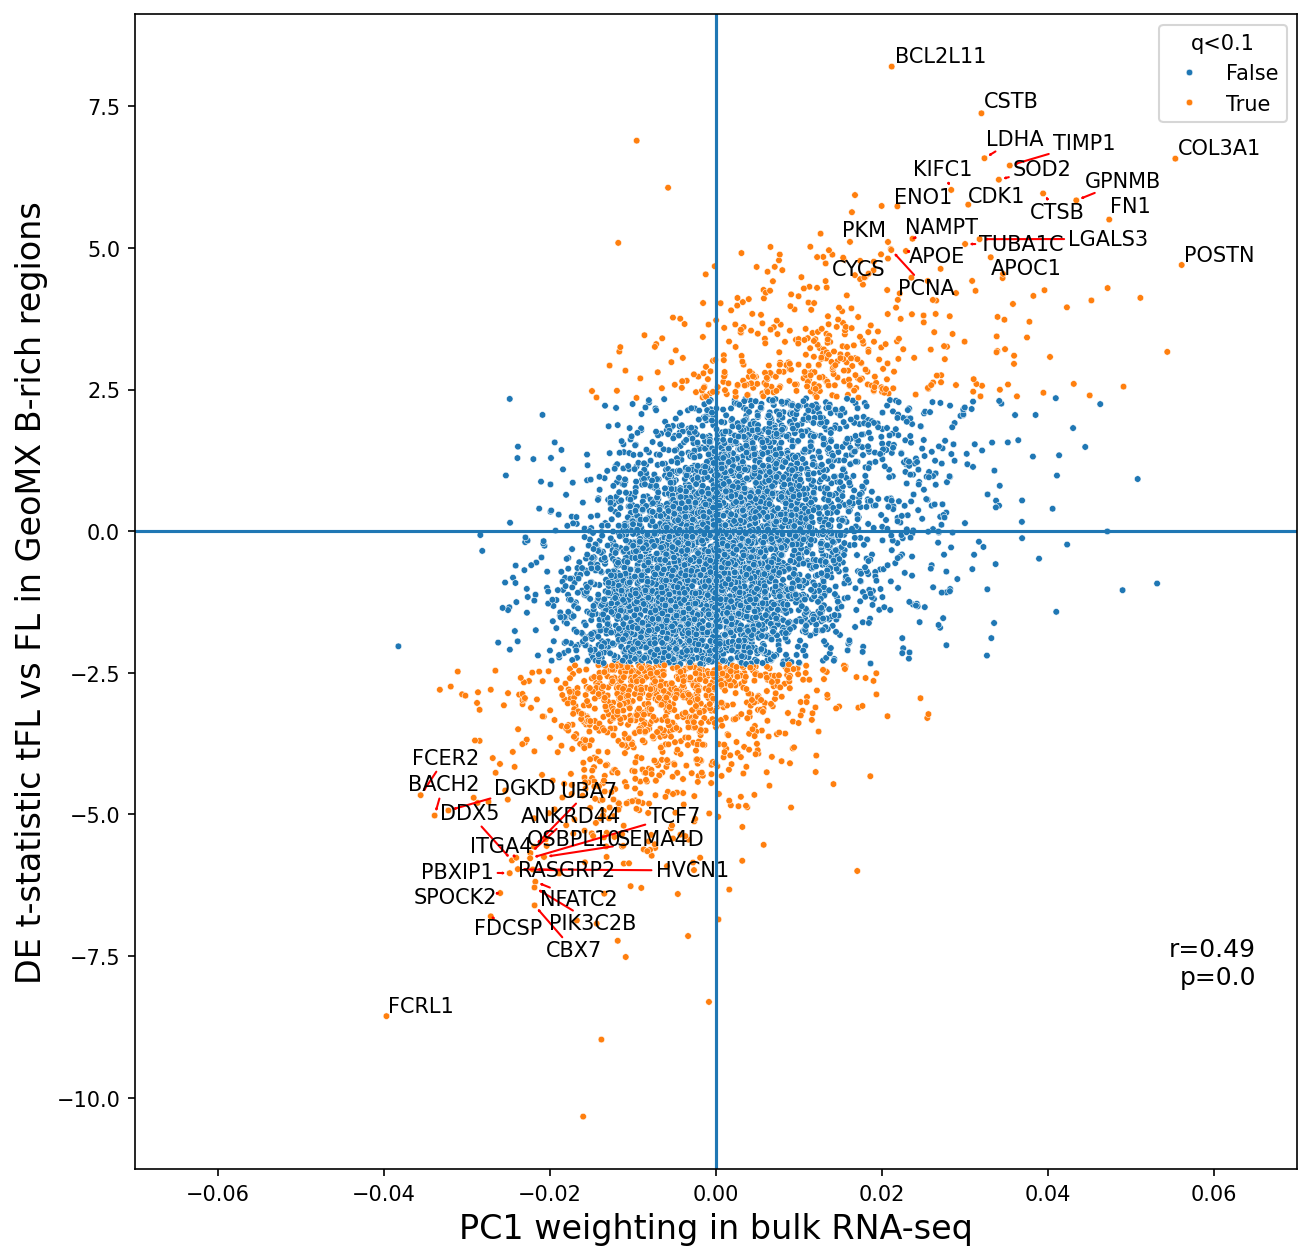

In [5]:
df['q<0.1'] = df['adj.P.Val'] < .1

plt.figure(figsize=(10,10))


# PC1 vs t-statistic scatterplot
sns.scatterplot(x='PC1',y='t',s=10,data=df,hue=df['q<0.1'])
plt.axvline(0)
plt.axhline(0)
plt.xlabel('PC1 weighting in bulk RNA-seq',fontsize=16)
plt.ylabel('DE t-statistic tFL vs FL in GeoMX B-rich regions',fontsize=16)

# Add pearson statistic
pres = pearsonr(df['PC1'],df['t'])
plt.text(.065,-8,f"r={pres[0]:.2f}\np={pres[1]}",ha='right',fontsize=12)
plt.xlim(-.07,.07)

# Select top genes to show names
idx = (df['adj.P.Val'] < 2.5e-4)&(np.abs(df['PC1'])>.02)&(np.abs(df['logFC']) > np.log2(1.5))
ts = list()
for gene,row in df[idx].iterrows():
    t = plt.text(x=row['PC1'],y=row['t'],s=gene)
    ts.append(t)
    
    
print(f"Showing {sum(idx)} genes")

adjust_text(ts,arrowprops=dict(arrowstyle='->', color='red'));

## Figure 2E - Heatmap of scRNA pseudobulk expression

In [6]:
import scanpy as sc
from ggsc.pseudobulk import calc_pseudobulk_tpm

In [7]:
adata_i = sc.read('../data/FL_scRNA_nonBcell_annotated.h5ad')
adata_t = sc.read('../data/FL_scRNA_Bcell_annotated.h5ad')

In [8]:
X_i= calc_pseudobulk_tpm(adata_i,groupby=['cell_type_coarse'])

Using total_counts for total counts column...


/home/njharlen/git/ggsctools/ggsc/pseudobulk.py:46: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_ref = ad.AnnData(X,var=adata_ref.var,obs=adata.obs)
/home/njharlen/git/ggsctools/ggsc/pseudobulk.py:48: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  T = pd.concat([_calc_tpm_singlegroup(adata_ref[g.index,:],total_counts_column).rename(ind)


In [9]:
X_t= calc_pseudobulk_tpm(adata_t,groupby=['patient'])

Using total_counts for total counts column...


/home/njharlen/git/ggsctools/ggsc/pseudobulk.py:46: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_ref = ad.AnnData(X,var=adata_ref.var,obs=adata.obs)
/home/njharlen/git/ggsctools/ggsc/pseudobulk.py:48: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  T = pd.concat([_calc_tpm_singlegroup(adata_ref[g.index,:],total_counts_column).rename(ind)


In [10]:
X = pd.concat([X_i,X_t],axis=0)

In [11]:
def plot_scRNA_heatmap(X,direction,top_n=25,min_PC = None,minFC = 1.5):
    
    if direction=='up':
        idx = (df['logFC'] > np.log2(minFC))
    else:
        idx = (df['logFC'] < -1*np.log2(minFC))
        
    if min_PC is not None:
        idx = idx & (np.abs(df['PC1']) > min_PC)

    genes = df[idx].sort_values('adj.P.Val').head(top_n).index

    X_plot = X[genes]
    X_plot = X_plot/X_plot.max()

    # Reorder so tumors are at end
    idx = X_plot.index.str.match('.FL')
    new_index = list(X_plot.index[~idx]) + list(X_plot.index[idx])
    X_plot = X_plot.loc[new_index]
    #X_plot.index = new_index

    h = sns.clustermap(X_plot,row_cluster=False,cmap="viridis")

    h.ax_heatmap.axhline(9,color='w',linewidth=5)

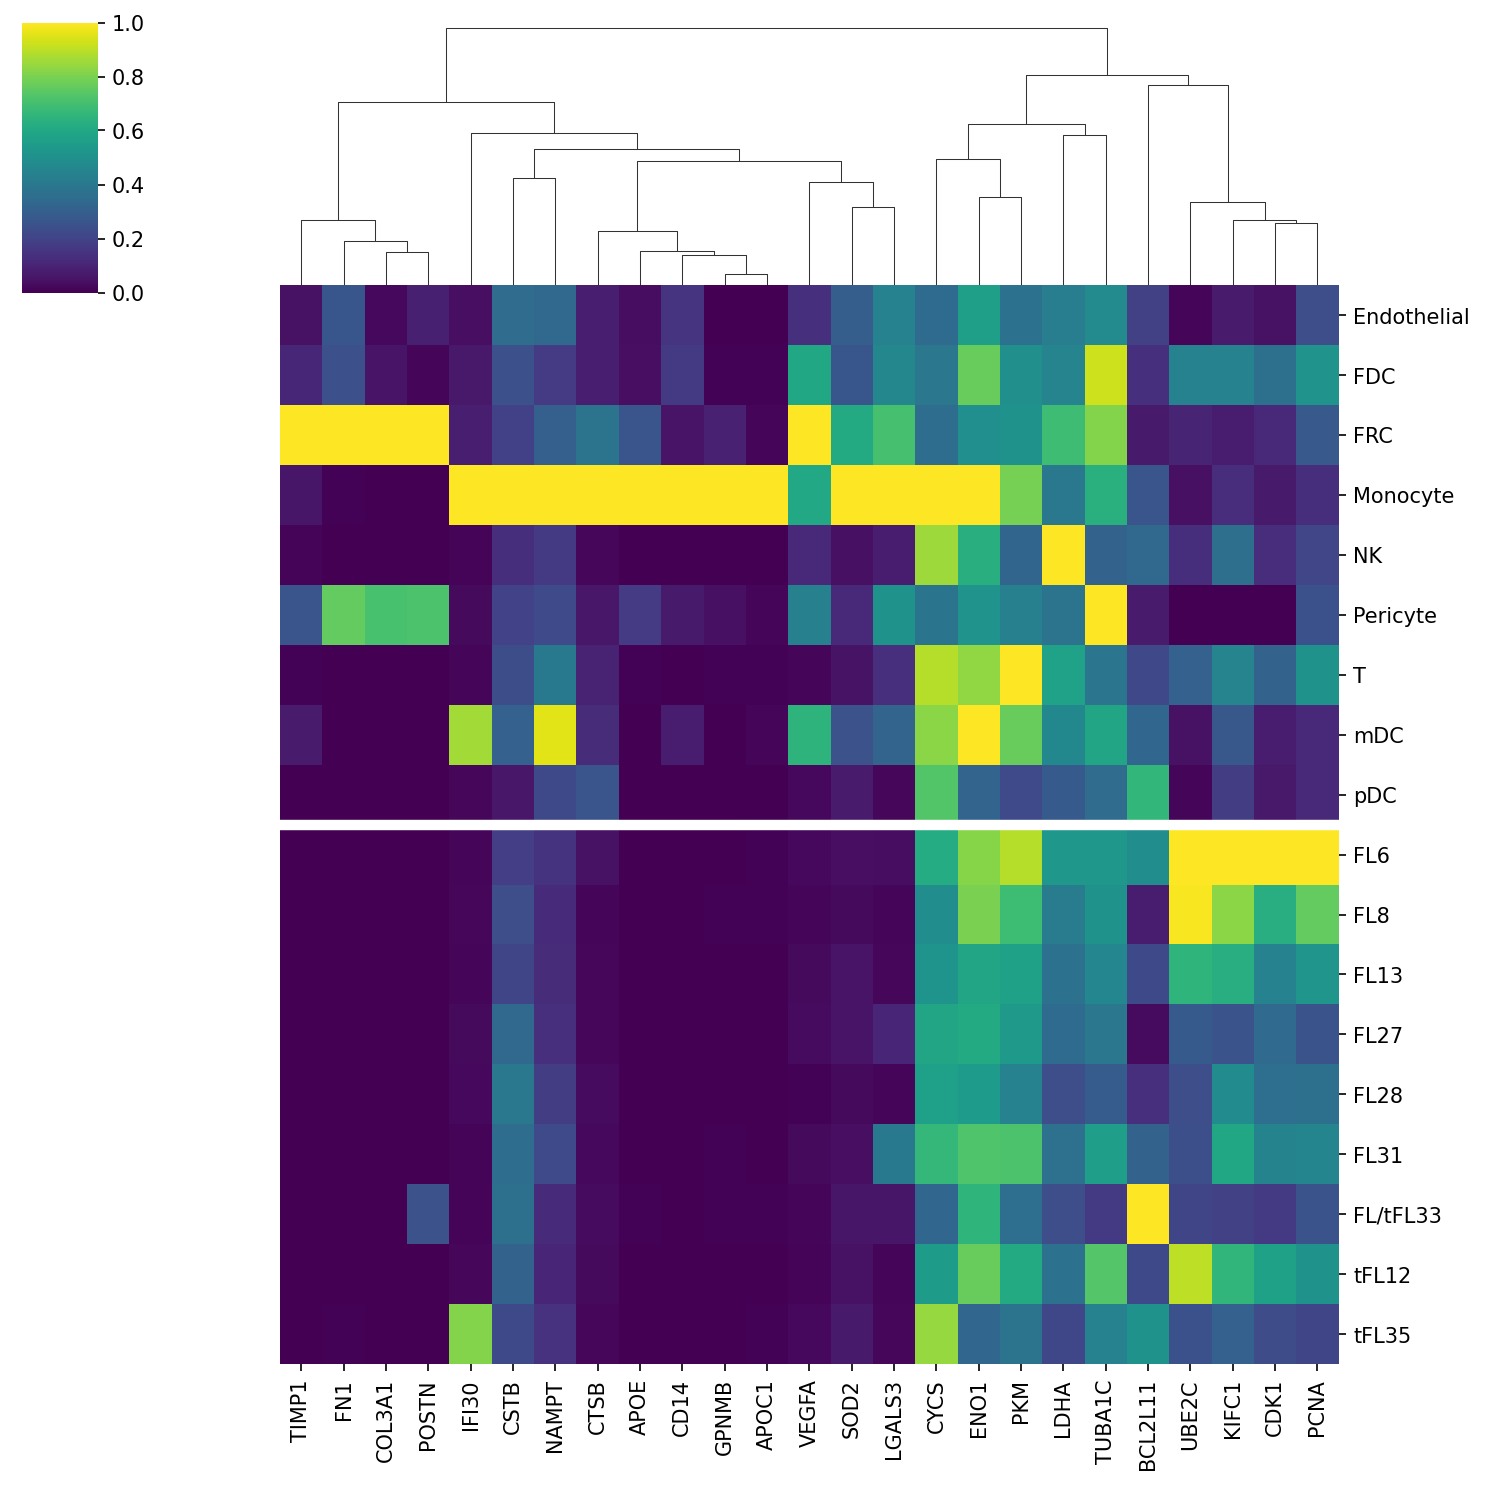

In [12]:
plot_scRNA_heatmap(X,'up',top_n = 25,min_PC=.02)


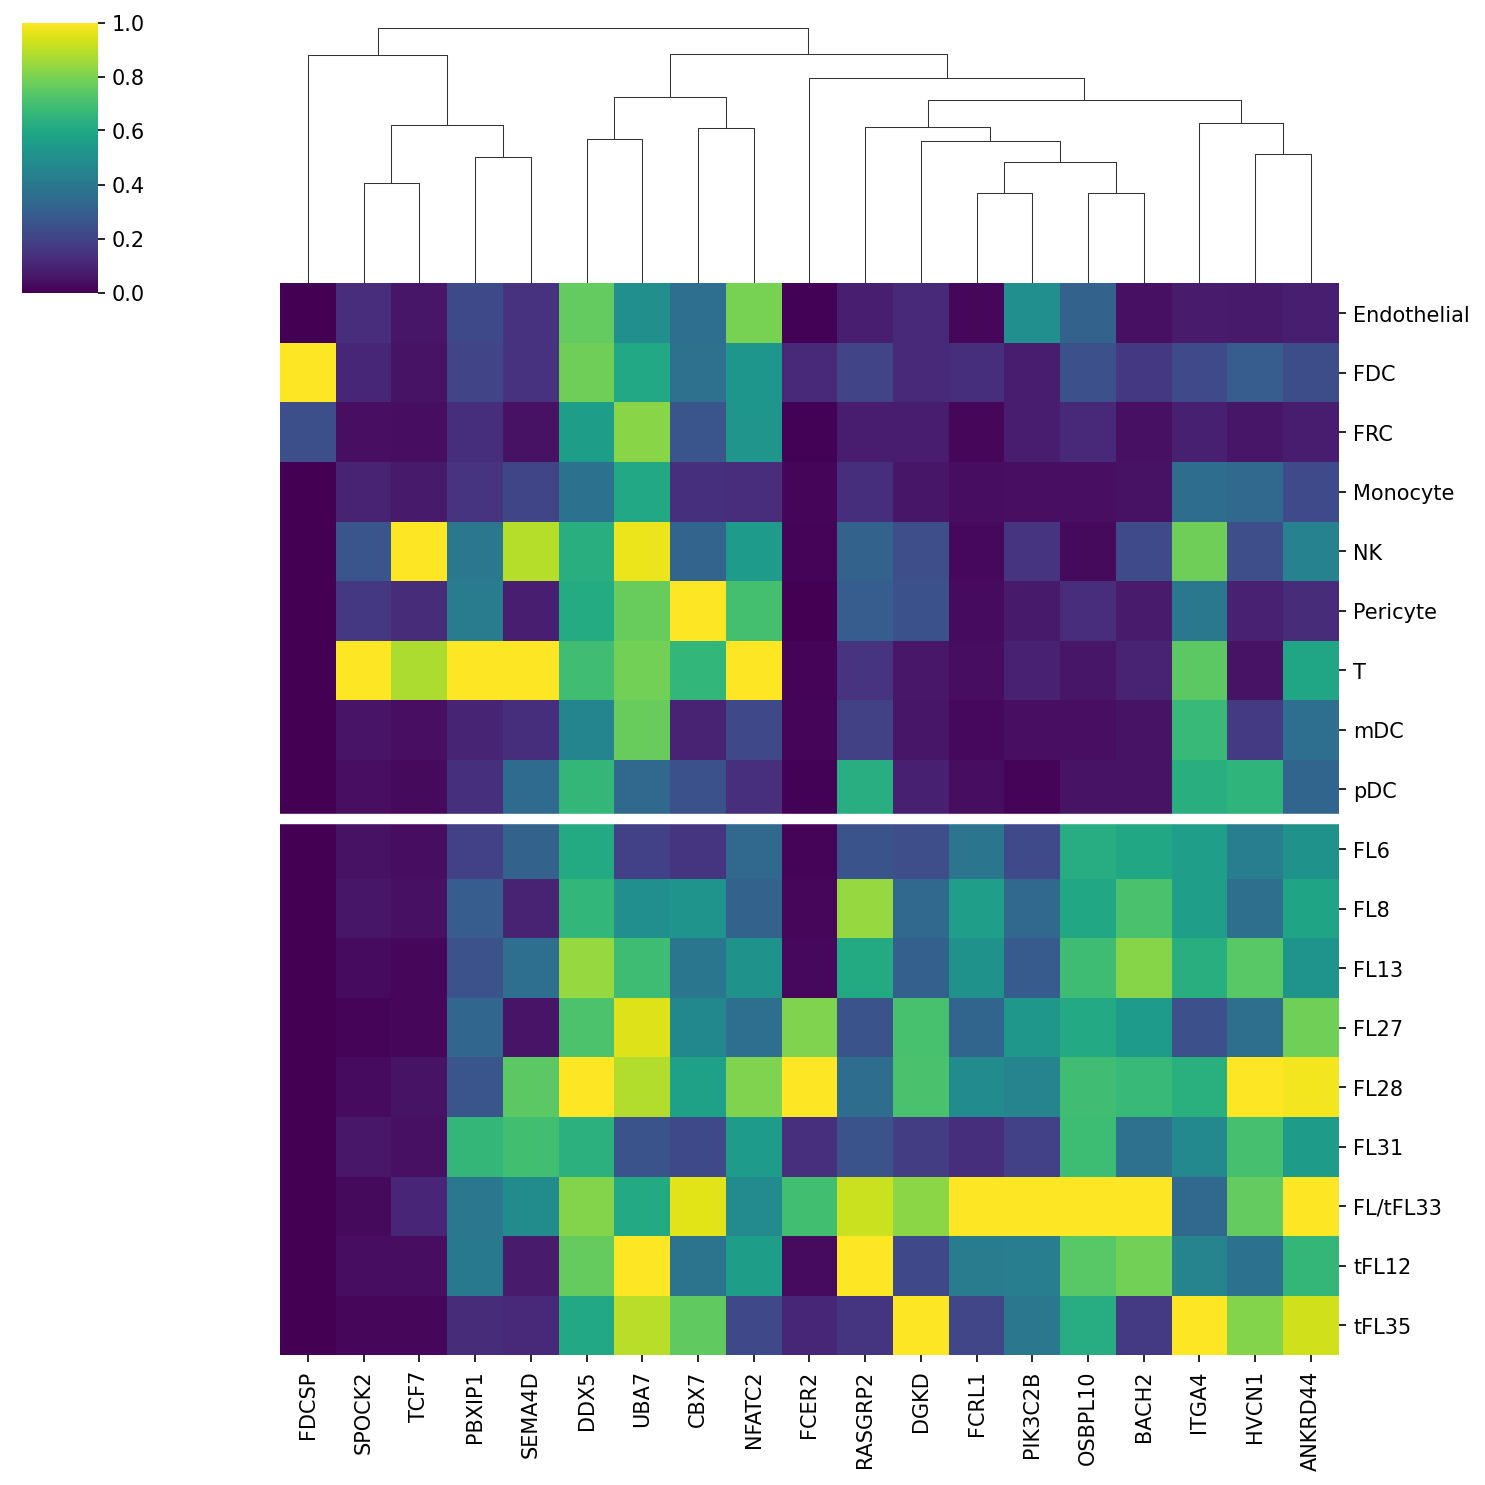

In [13]:
plot_scRNA_heatmap(X,'down',top_n = 25,min_PC=.02)
